Garment Inc is a corporation that handles clothing exports to customers all over Europe. They cater to wholesale business where customers are buying their products either in bulk or retail. 
In order to increase customer retention, the business needs to determine their distinct customer groups to see their purchase behavior so they could take actions for each group. 

After data is preprocessed, check for recent transactions,
frequency and the amount spent by the customers. In order to
create recency variable, decide the reference date - that is one
day prior to the last transaction. RFM analysis is a very popular
customer segmentation and identifiable technique in database
marketing (Christy et al., 2018). It is significant especially in
Retail Industry. Each customer under RFM is scored based on
three factors.
1.  Recency: It refers to the number of days before the reference
date when a customer made the last purchase. Lesser the value
of recency, higher is the customer visit to a store.
2. Frequency: It is the period between two subsequent purchases
of a customer. Higher the value of Frequency, more is the customer visit to the company.
3. Monetary: This refers to the amount of money spent by a customer during a specific period of time. Higher the value, more
is the profit generated to the company

# Imports

In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta
import seaborn as sns 

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score


# EDA

In [102]:
df = pd.read_excel("Transactions_LRFM.xlsx")
df




,TRANSACTION_ID,TRANSACTION_DATE,TOTAL_PRICE,CUSTOMER_ID,LOGISTIC_ID,SHIPMENT_CITY,SHIPMENT_COUNTRY,PRODUCT_ID,QUANTITY,PRODUCT_PRICE,PRODUCT_COST,Business Transaction,Product_Category,customer_since_year
0,1025189,2023-01-21,11720,25,4,Dublin,Ireland,38,320,2240,1280,Retail,Sweatshirt,2015
1,1025189,2023-01-21,11720,25,4,Dublin,Ireland,105,290,6380,4350,Retail,Polo Shirt,2015
2,1025189,2023-01-21,11720,25,4,Dublin,Ireland,77,310,3100,2015,Retail,T-Shirt,2015
3,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,56,670,20100,11725,Bulk,Cardigan,2015
4,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,105,740,16280,11100,Bulk,Polo Shirt,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110182,1060186,2023-12-28,48940,8,14,Wigan,UK,80,1210,12100,7865,Retail,T-Shirt,2006
110183,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,59,90,2700,1575,Bulk,Cardigan,2009
110184,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,27,760,13680,7600,Bulk,Hoodie,2009
110185,1060188,2023-04-28,11440,3,12,Hamburg,Germany,77,120,1200,780,Others,T-Shirt,2002


In [4]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 14.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [103]:
df.drop_duplicates()

,TRANSACTION_ID,TRANSACTION_DATE,TOTAL_PRICE,CUSTOMER_ID,LOGISTIC_ID,SHIPMENT_CITY,SHIPMENT_COUNTRY,PRODUCT_ID,QUANTITY,PRODUCT_PRICE,PRODUCT_COST,Business Transaction,Product_Category,customer_since_year
0,1025189,2023-01-21,11720,25,4,Dublin,Ireland,38,320,2240,1280,Retail,Sweatshirt,2015
1,1025189,2023-01-21,11720,25,4,Dublin,Ireland,105,290,6380,4350,Retail,Polo Shirt,2015
2,1025189,2023-01-21,11720,25,4,Dublin,Ireland,77,310,3100,2015,Retail,T-Shirt,2015
3,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,56,670,20100,11725,Bulk,Cardigan,2015
4,1025190,2023-08-17,36380,24,4,Ludwigshafen am Rhein,Germany,105,740,16280,11100,Bulk,Polo Shirt,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110182,1060186,2023-12-28,48940,8,14,Wigan,UK,80,1210,12100,7865,Retail,T-Shirt,2006
110183,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,59,90,2700,1575,Bulk,Cardigan,2009
110184,1060187,2023-03-15,16380,13,15,Almere Stad,Netherlands,27,760,13680,7600,Bulk,Hoodie,2009
110185,1060188,2023-04-28,11440,3,12,Hamburg,Germany,77,120,1200,780,Others,T-Shirt,2002


# Cleaning

In [104]:
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])


# LRFM

first we started by determining the snapshot date, which marks a point in time for data reporting/analysis. In this case, we made it 1 day after last transaction.

In [105]:
snapshot_date = df['TRANSACTION_DATE'].max() + pd.Timedelta(days=30)
snapshot_date

Timestamp('2024-01-30 00:00:00')

## Build LRFM features

We grouped the transactions invoice by customer id to cluster each invoice by its respective customer. To then, we determine their first vs last purchase for the LRFM columns. 

In [106]:
lrfm = df.groupby("CUSTOMER_ID").agg({
    'TRANSACTION_DATE': ['min','max','count'],
    'TOTAL_PRICE': 'sum'
})



In [107]:
lrfm.columns = ['first_purchase','last_purchase','F','M']


In [108]:
lrfm['R'] = (snapshot_date - lrfm['last_purchase']).dt.days
lrfm['L'] = (lrfm['last_purchase'] - lrfm['first_purchase']).dt.days

In [110]:
lrfm_features = lrfm[['L','R','F','M']]



In [111]:
lrfm


,first_purchase,last_purchase,F,M,R,L
CUSTOMER_ID,,,,,,
1,2023-01-01,2023-12-31,2544,97828660,30,364
2,2023-01-02,2023-12-31,1501,61316830,30,363
3,2023-01-01,2023-12-31,2480,94721220,30,364
4,2023-01-01,2023-12-30,1535,62710350,31,363
5,2023-01-01,2023-12-31,2765,104411690,30,364
6,2023-01-01,2023-12-31,2660,104527130,30,364
7,2023-01-02,2023-12-31,2582,100297100,30,363
8,2023-01-01,2023-12-31,2631,103293800,30,364
9,2023-01-02,2023-12-31,2424,86184580,30,363


In [112]:
lrfm = lrfm.drop(columns=['first_purchase','last_purchase'])


In [113]:
lrfm

,F,M,R,L
CUSTOMER_ID,,,,
1,2544,97828660,30,364
2,1501,61316830,30,363
3,2480,94721220,30,364
4,1535,62710350,31,363
5,2765,104411690,30,364
6,2660,104527130,30,364
7,2582,100297100,30,363
8,2631,103293800,30,364
9,2424,86184580,30,363


In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lrfm[['L','R','F','M']])


In [15]:

wcss = []
K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(K, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

C:\Users\amali\AppData\Local\Temp\ipykernel_12416\1092927896.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [16]:
%matplotlib inline


In [17]:


silhouette_scores = {}

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_scores


{2: 0.6802555546296357,
 3: 0.6932865804517786,
 4: 0.7573948981167442,
 5: 0.785933088524995,
 6: 0.7761246780971516,
 7: 0.7330604638384295,
 8: 0.5427353455697389,
 9: 0.5030987480720102,
 10: 0.4862928812863858}

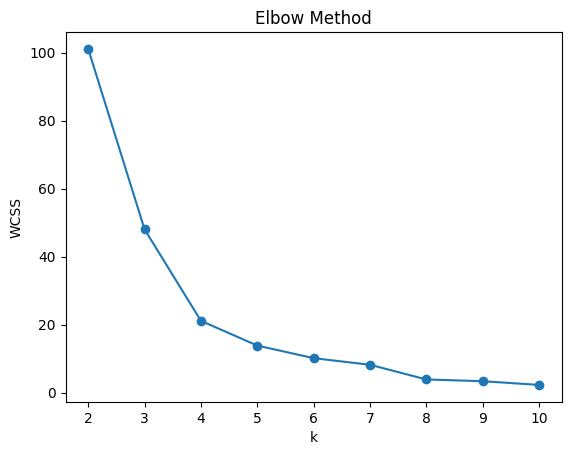

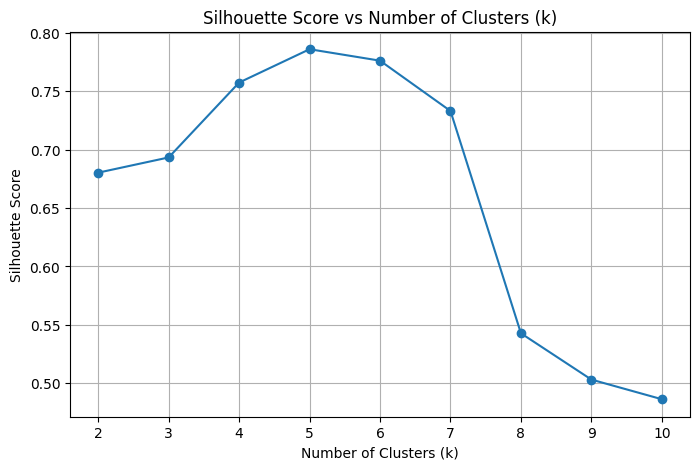

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(list(silhouette_scores.keys()),
         list(silhouette_scores.values()),
         marker='o')

plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(silhouette_scores.keys()))
plt.grid(True)

plt.show()



In [19]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42)
lrfm['KMeansCluster'] = kmeans.fit_predict(X_scaled)


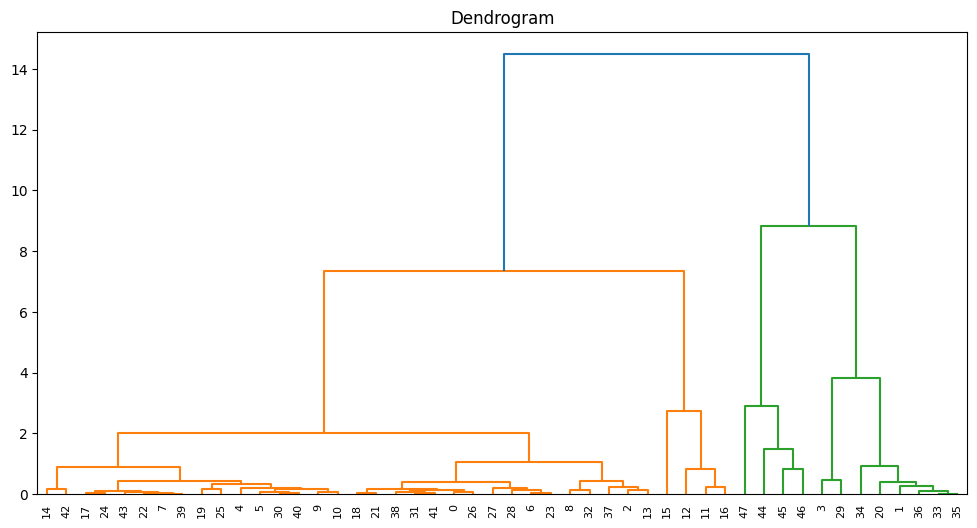

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()


In [21]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
lrfm['AggCluster'] = agg.fit_predict(X_scaled)


In [ ]:
from sklearn.cluster import DBSCAN


list_eps = [0.2, 0.3, 0.4, 0.5]
list_min_samples = [4, 5, 6, 7]

results = []

for eps in list_eps:
    for min_samples in list_min_samples:

        print(f"--- eps={eps}, min_samples={min_samples} ---")

        # Fit DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        unique_labels = np.unique(labels)
        print("Cluster labels:", unique_labels)

        # Count members per cluster (handling -1 noise)
        counts = np.bincount(labels + 1)
        print("Members per cluster:", counts)

        # Compute silhouette score ONLY if DBSCAN created ≥ 2 clusters
        if len(unique_labels[unique_labels != -1]) >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1  # invalid silhouette condition

        print("Silhouette Score:", sil)
        print()

        # Save results
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "silhouette": sil,
            "clusters": unique_labels,
            "members": counts
        })



--- eps=0.2, min_samples=4 ---
Cluster labels: [-1  0  1]
Members per cluster: [ 8 35  5]
Silhouette Score: 0.6598924605676797

--- eps=0.2, min_samples=5 ---
Cluster labels: [-1  0]
Members per cluster: [15 33]
Silhouette Score: -1

--- eps=0.2, min_samples=6 ---
Cluster labels: [-1  0]
Members per cluster: [15 33]
Silhouette Score: -1

--- eps=0.2, min_samples=7 ---
Cluster labels: [-1  0]
Members per cluster: [15 33]
Silhouette Score: -1

--- eps=0.3, min_samples=4 ---
Cluster labels: [-1  0  1]
Members per cluster: [ 4 36  8]
Silhouette Score: 0.7576438852937043

--- eps=0.3, min_samples=5 ---
Cluster labels: [-1  0  1]
Members per cluster: [ 4 36  8]
Silhouette Score: 0.7576438852937043

--- eps=0.3, min_samples=6 ---
Cluster labels: [-1  0  1]
Members per cluster: [ 6 34  8]
Silhouette Score: 0.6690192901603577

--- eps=0.3, min_samples=7 ---
Cluster labels: [-1  0  1]
Members per cluster: [ 7 34  7]
Silhouette Score: 0.650449364257737

--- eps=0.4, min_samples=4 ---
Cluster labe

In [38]:
dbscan_result = pd.DataFrame(results)

dbscan_result = dbscan_result.sort_values(
    by="silhouette",
    ascending=False
).reset_index(drop=True)

dbscan_result



,eps,min_samples,silhouette,clusters,members
0,0.5,4,0.853079,"[0, 1]","[0, 36, 12]"
1,0.3,5,0.757644,"[-1, 0, 1]","[4, 36, 8]"
2,0.4,5,0.757644,"[-1, 0, 1]","[4, 36, 8]"
3,0.3,4,0.757644,"[-1, 0, 1]","[4, 36, 8]"
4,0.4,6,0.757644,"[-1, 0, 1]","[4, 36, 8]"
5,0.4,7,0.757644,"[-1, 0, 1]","[4, 36, 8]"
6,0.5,5,0.727181,"[-1, 0, 1]","[1, 36, 11]"
7,0.5,6,0.727181,"[-1, 0, 1]","[1, 36, 11]"
8,0.5,7,0.727181,"[-1, 0, 1]","[1, 36, 11]"
9,0.4,4,0.695520,"[-1, 0, 1]","[1, 36, 11]"


In [58]:
# Fit DBScan
dbscan = DBSCAN(eps=0.5, min_samples=4)
clusters_dbs = dbscan.fit_predict(X_scaled)

print('cluster: \n',clusters_dbs)

cluster: 
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1
 0 0 0 0 0 0 0 1 1 1 1]


In [57]:
print('Silhouette score DBScan:', silhouette_score(X_scaled, clusters_dbs))

Silhouette score DBScan: 0.8530791078584663


In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
db_labels = dbscan.fit_predict(X_scaled)




array([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1])

In [52]:
lrfm['DBScan'] = db_labels


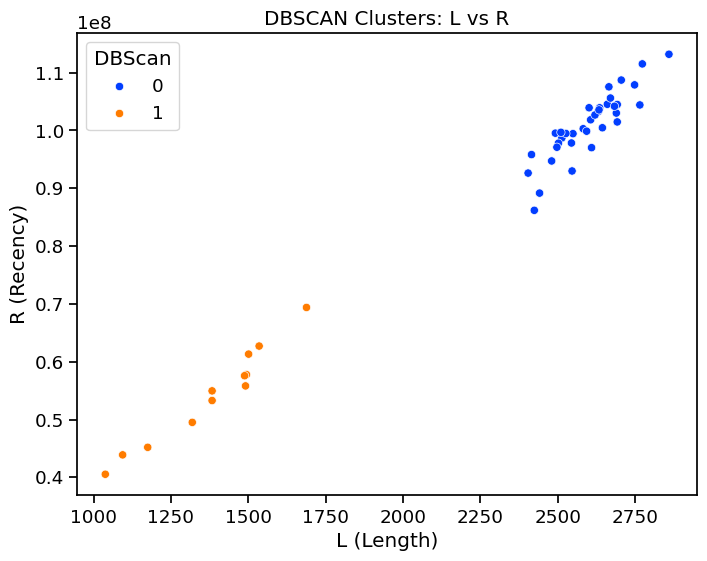

In [60]:


plt.figure(figsize=(8,6))
sns.scatterplot(
    x='F',
    y='M',
    hue='DBScan',
    data=lrfm,
    palette='bright'
)
plt.xlabel('L (Length)')
plt.ylabel('R (Recency)')
plt.title('DBSCAN Clusters: L vs R')
plt.show()


In [47]:
lrfm.columns


Index(['first_purchase', 'last_purchase', 'F', 'M', 'R', 'L', 'S', 'S_score',
       'cluster', 'segment'],
      dtype='object')

In [25]:
lrfm = df.groupby("CUSTOMER_ID").agg({
    'TRANSACTION_DATE': ['min','max','count'],
    'TOTAL_PRICE': 'sum'
})

lrfm.columns = ['first_purchase','last_purchase','F','M']

# Recency & Lifetime
lrfm['R'] = (snapshot_date - lrfm['last_purchase']).dt.days
lrfm['L'] = (lrfm['last_purchase'] - lrfm['first_purchase']).dt.days
 #spending score
lrfm['S'] = lrfm['M'] / lrfm['F']


In [26]:
# Min-max normalization to 0–100
min_S = lrfm['S'].min()
max_S = lrfm['S'].max()

lrfm['S_score'] = ((lrfm['S'] - min_S) / (max_S - min_S)) * 100


In [27]:
lrfm

,first_purchase,last_purchase,F,M,R,L,S,S_score
CUSTOMER_ID,,,,,,,,
1,2023-01-01,2023-12-31,2544,97828660,1,364,38454.661950,52.242598
2,2023-01-02,2023-12-31,1501,61316830,1,363,40850.652898,95.406118
3,2023-01-01,2023-12-31,2480,94721220,1,364,38194.040323,47.547528
4,2023-01-01,2023-12-30,1535,62710350,2,363,40853.648208,95.460078
5,2023-01-01,2023-12-31,2765,104411690,1,364,37761.913201,39.762804
6,2023-01-01,2023-12-31,2660,104527130,1,364,39295.913534,67.397655
7,2023-01-02,2023-12-31,2582,100297100,1,363,38844.732765,59.269682
8,2023-01-01,2023-12-31,2631,103293800,1,364,39260.281262,66.755744
9,2023-01-02,2023-12-31,2424,86184580,1,363,35554.694719,0.000000


In [ ]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(lrfm[['F','M']])





In [62]:
kmeans = KMeans(n_clusters=5, random_state=42)
lrfm['cluster'] = kmeans.fit_predict(X_scaled)



In [61]:
sil = silhouette_score(X_scaled, lrfm['cluster'])
sil


0.5083792897765215

In [32]:
cluster_profile = lrfm.groupby('cluster')[['L','R','F','M','S','S_score']].mean().round(2)
cluster_profile



,L,R,F,M,S,S_score
cluster,,,,,,
0,363.79,1.16,2682.68,1.050639e+08,39163.92,65.02
1,315.67,1.67,1361.67,5.258523e+07,38601.60,54.89
2,363.50,1.17,1532.83,6.076366e+07,39601.85,72.91
3,363.59,1.12,2507.47,9.636801e+07,38429.91,51.80
4,219.33,1.67,1102.33,4.320836e+07,39212.80,65.90


In [33]:
label_map = {
    cluster_profile['M'].idxmax(): "VIP",
    cluster_profile['M'].sort_values(ascending=False).index[1]: "Loyal",
    cluster_profile['R'].idxmax(): "At_Risk",
    cluster_profile['M'].idxmin(): "Low_Value"
}

lrfm['segment'] = lrfm['cluster'].map(label_map)



In [64]:
print(lrfm.columns.tolist())
print(lrfm.head())


['first_purchase', 'last_purchase', 'F', 'M', 'R', 'L', 'S', 'S_score', 'cluster', 'segment', 'DBScan']
            first_purchase last_purchase     F          M  R    L  \
CUSTOMER_ID                                                         
1               2023-01-01    2023-12-31  2544   97828660  1  364   
2               2023-01-02    2023-12-31  1501   61316830  1  363   
3               2023-01-01    2023-12-31  2480   94721220  1  364   
4               2023-01-01    2023-12-30  1535   62710350  2  363   
5               2023-01-01    2023-12-31  2765  104411690  1  364   

                        S    S_score  cluster segment  DBScan  
CUSTOMER_ID                                                    
1            38454.661950  52.242598        3   Loyal       0  
2            40850.652898  95.406118        2     NaN       1  
3            38194.040323  47.547528        3   Loyal       0  
4            40853.648208  95.460078        2     NaN       1  
5            37761.913201  3

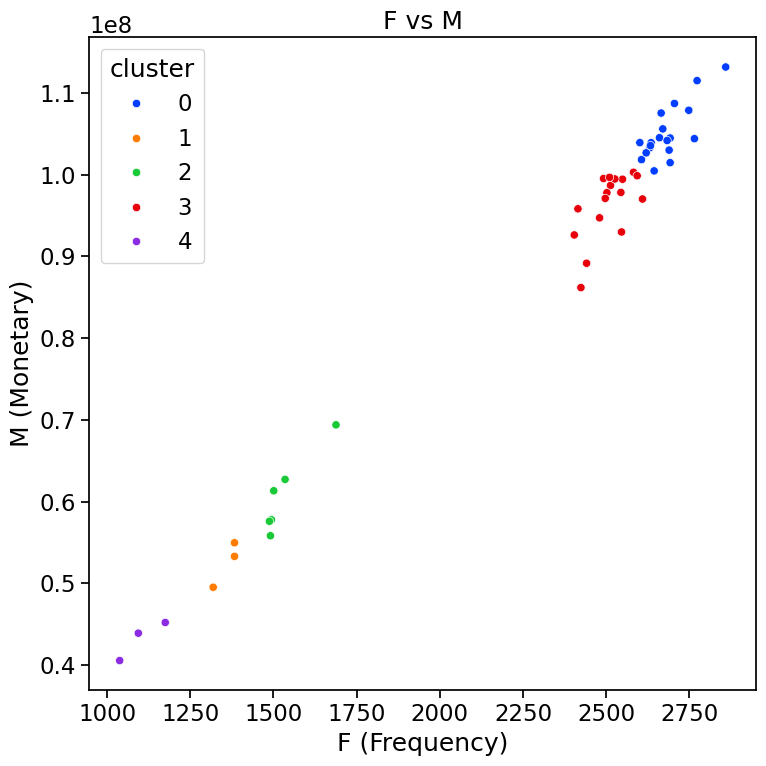

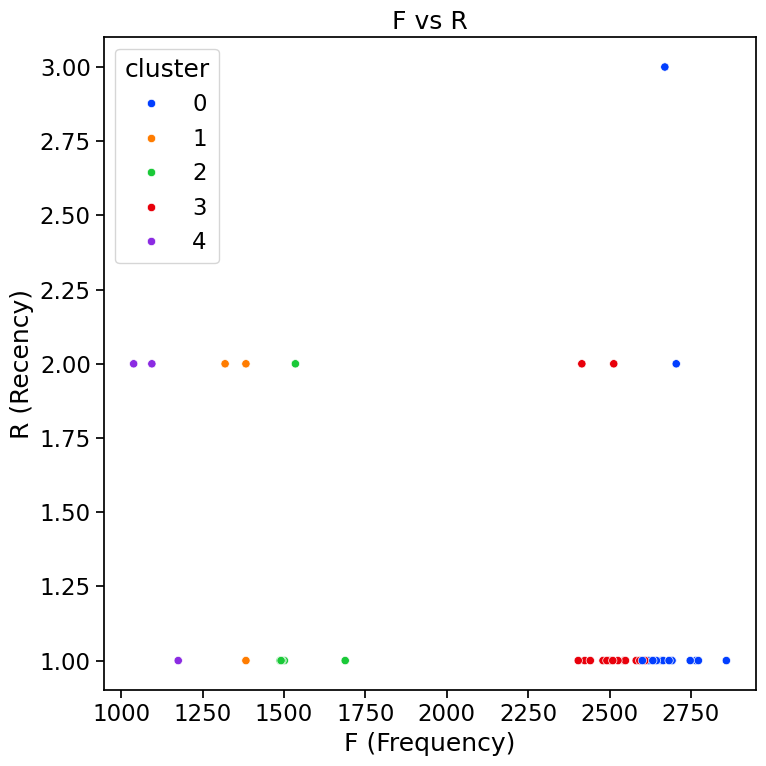

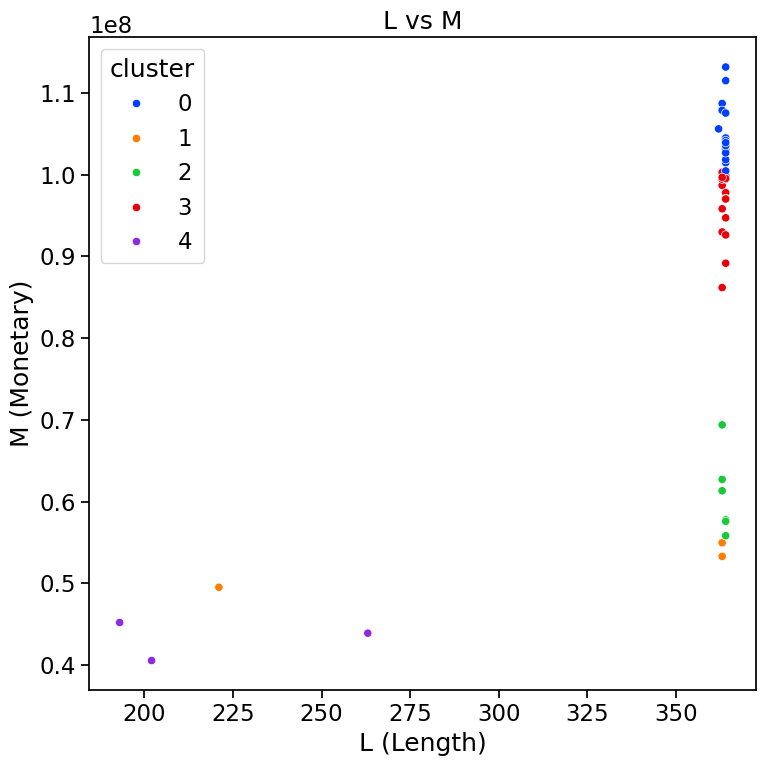

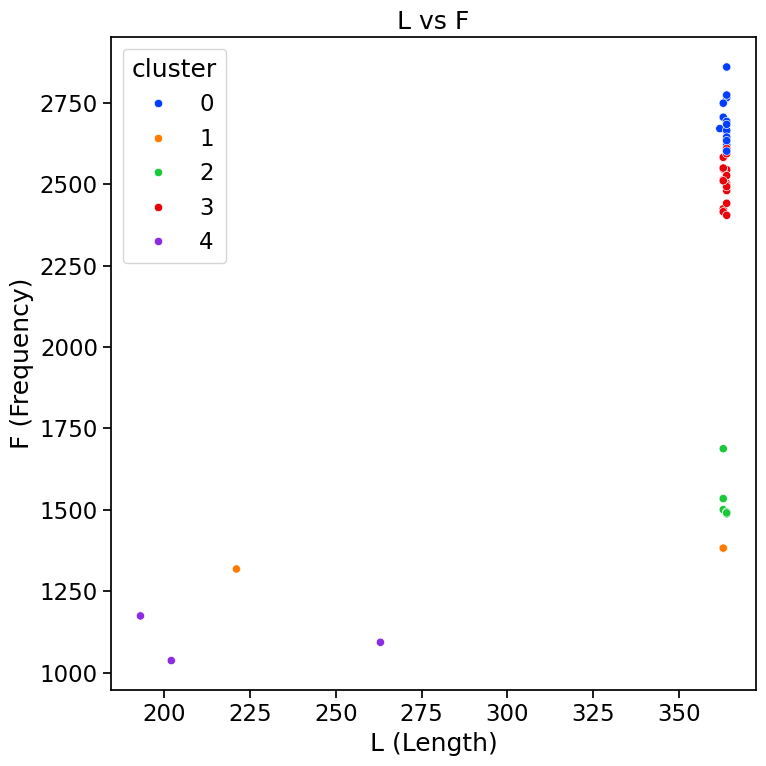

In [73]:
cluster_col = 'cluster'
sns.set_context('notebook', font_scale=1.5)




# --- F vs M ---
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='F',
    y='M',
    hue=cluster_col,
    data=lrfm,
    palette='bright'
)
plt.xlabel('F (Frequency)')
plt.ylabel('M (Monetary)')
plt.title('F vs M')
plt.tight_layout()
plt.show()


# --- F vs R ---
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='F',
    y='R',
    hue=cluster_col,
    data=lrfm,
    palette='bright'
)
plt.xlabel('F (Frequency)')
plt.ylabel('R (Recency)')
plt.title('F vs R')
plt.tight_layout()
plt.show()




# --- L vs M ---
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='L',
    y='M',
    hue=cluster_col,
    data=lrfm,
    palette='bright'
)
plt.xlabel('L (Length)')
plt.ylabel('M (Monetary)')
plt.title('L vs M')
plt.tight_layout()
plt.show()


# --- L vs F ---
plt.figure(figsize=(8,8))
sns.scatterplot(
    x='L',
    y='F',
    hue=cluster_col,
    data=lrfm,
    palette='bright'
)
plt.xlabel('L (Length)')
plt.ylabel('F (Frequency)')
plt.title('L vs F')
plt.tight_layout()
plt.show()
